# Notebook 02a - Procedure Profiling & Peer Grouping

**Project:** Provider Aberrant Billing Pattern Detection (P3)  
**Upstream:** Notebook 01 (data quality contract), Snowflake exports  
**Downstream:** Notebook 02b (provider profiling & clustering)

---

## Purpose

Before detecting aberrant billing, we must define **what "normal" looks like** - and that requires grouping providers into homogeneous peer groups. This notebook builds the grouping methodology from first principles:

1. **Procedure universe profiling** - classify every HCPCS code into clinical tiers
2. **Provider clinical identity** - assign each provider their primary *index* procedure (not just most-frequent code)
3. **Peer group construction** - naive (broad specialty) vs improved (index-code-level)
4. **Statistical validation** - formal tests proving the improved grouping is more homogeneous

The key insight: a provider's peer group should be determined by *what they do clinically*, not by an arbitrary HCPCS code that happens to appear most often. A cardiologist whose most-billed code is 36415 (venipuncture) is still a cardiologist - their index procedure is the E&M or diagnostic code that defines their clinical function.

**A note on technology choices:** This project deliberately implements the same analytical pipeline across Snowflake (SQL), SAS, and Python/DuckDB. In a production setting, a single technology stack would be selected.

In [1]:
import sys
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

pd.set_option('display.float_format', lambda x: f'{x:.8f}')

from pathlib import Path
_cwd = Path.cwd()
if (_cwd / 'src').is_dir():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / 'src').is_dir():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = Path('/home/aosousa/Documents/PORTFOLIO/Fraud-Waste-Abuse-FWA/'
                        'CMS DE-SynPUF MEDICARE/provider-aberrant-billing-detection')
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    FIGURES_DIR, OUTPUT_DIR, SNOWFLAKE_EXPORTS_DIR,
    MIN_CLAIMS, MIN_PEER_GROUP_SIZE,
)
from src.visual_identity import *
from src.data_loader import load_snowflake_export

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"Visual identity loaded. Serif: {SERIF} | Sans: {SANS}")

Visual identity loaded. Serif: Liberation Serif | Sans: Liberation Sans


## 1. Load data

In [2]:
df_metrics = load_snowflake_export('billing_metrics')
df_dim_prov = load_snowflake_export('dim_provider')

# Merge top_hcpcs_code onto billing metrics
if 'top_hcpcs_code' not in df_metrics.columns:
    df_metrics = df_metrics.merge(
        df_dim_prov[['provider_npi', 'top_hcpcs_code']],
        on='provider_npi', how='left'
    )

# Apply minimum claims filter (quality contract)
before = len(df_metrics)
print(f"Loaded: {before:,} providers")
df = df_metrics[df_metrics['total_claims'] >= MIN_CLAIMS].copy()
print(f"After MIN_CLAIMS={MIN_CLAIMS} filter: {len(df):,} retained")
print(f"Unique top HCPCS codes: {df['top_hcpcs_code'].nunique()}")

Loaded: 893,020 providers
After MIN_CLAIMS=30 filter: 477,598 retained
Unique top HCPCS codes: 504


## 2. Procedure universe profiling

### 2.1 HCPCS/CPT code classification

The CPT/HCPCS code structure provides a built-in clinical hierarchy. We classify every code into four tiers based on its clinical role:

| Tier | Role | Examples | Peer grouping? |
|---|---|---|---|
| **Tier 1 - Index procedures** | Define what the provider *does* clinically | E&M visits (99211–99215), hospital care (99221–99233), surgeries | ✓ Primary peer group key |
| **Tier 2 - Diagnostic/therapeutic** | What they order or perform | Lab tests (80047–89398), imaging, PT, injections | ✓ Secondary key (if no Tier 1) |
| **Tier 3 - Ancillary/support** | High volume, low clinical specificity | Venipuncture (36415), specimen handling, ECG tracing only | ✗ Skip - reassign to Tier 1/2 |
| **Tier 4 - HCPCS Level II** | Supplies, drugs, DME, transport | A-codes (ambulance), J-codes (drugs), E-codes (DME) | ✓ Separate peer universe |

This classification is a simplified proxy. In production, CMS BETOS (Berenson-Eggers Type of Service) or the AMA CPT category system would be used.

In [3]:
# =============================================================================
# HCPCS/CPT classification function
# =============================================================================

def classify_hcpcs(code):
    """Classify a HCPCS/CPT code into tier and category.

    Returns (tier, category) tuple.
    Tier 1 = Index, Tier 2 = Diagnostic/Therapeutic,
    Tier 3 = Ancillary, Tier 4 = HCPCS Level II.
    """
    if pd.isna(code) or code == '':
        return (0, 'Unknown')

    code = str(code).strip()

    # --- Tier 3: Ancillary codes (must check FIRST - these override numeric ranges) ---
    ancillary_codes = {
        '36415': 'Venipuncture',
        '36416': 'Capillary blood collection',
        '99000': 'Specimen handling',
        '99001': 'Specimen transport',
        '93005': 'ECG tracing only',
        '93041': 'Rhythm ECG tracing',
        '93042': 'Rhythm ECG interpretation',
        '99024': 'Postop follow-up (no charge)',
        '99050': 'After-hours service',
        '99058': 'Emergency service',
    }
    if code in ancillary_codes:
        return (3, f'Ancillary - {ancillary_codes[code]}')

    # --- Tier 4: HCPCS Level II (alpha prefix) ---
    if code[0].isalpha():
        prefix = code[0]
        level2_map = {
            'A': 'Transport & supplies',
            'B': 'Enteral/parenteral',
            'C': 'Hospital outpatient',
            'D': 'Dental',
            'E': 'DME',
            'G': 'Temporary procedures',
            'H': 'Behavioral health',
            'J': 'Injectable drugs',
            'K': 'DME (temporary)',
            'L': 'Orthotics/prosthetics',
            'M': 'Quality measures',
            'P': 'Lab (pathology)',
            'Q': 'Temporary codes',
            'R': 'Radiology',
            'S': 'Commercial payers',
            'T': 'Medicaid',
            'V': 'Vision/hearing',
        }
        category = level2_map.get(prefix, 'Other Level II')
        return (4, f'HCPCS Level II - {category}')

    # --- Numeric CPT codes ---
    try:
        num = int(code)
    except ValueError:
        return (0, 'Unknown')

    # Tier 1: Index procedures
    if 99201 <= num <= 99499:
        if 99201 <= num <= 99215:
            return (1, 'E&M - Office/outpatient visit')
        elif 99221 <= num <= 99233:
            return (1, 'E&M - Hospital inpatient')
        elif 99238 <= num <= 99239:
            return (1, 'E&M - Hospital discharge')
        elif 99281 <= num <= 99285:
            return (1, 'E&M - Emergency department')
        elif 99241 <= num <= 99245:
            return (1, 'E&M - Consultation')
        elif 99304 <= num <= 99318:
            return (1, 'E&M - Nursing facility')
        elif 99341 <= num <= 99350:
            return (1, 'E&M - Home visit')
        elif 99381 <= num <= 99397:
            return (1, 'E&M - Preventive visit')
        elif 99460 <= num <= 99465:
            return (1, 'E&M - Newborn care')
        else:
            return (1, 'E&M - Other')

    if 10021 <= num <= 69990:
        if 10021 <= num <= 10022:
            return (1, 'Surgery - Fine needle aspiration')
        elif 10040 <= num <= 19499:
            return (1, 'Surgery - Integumentary')
        elif 20000 <= num <= 29999:
            return (1, 'Surgery - Musculoskeletal')
        elif 30000 <= num <= 32999:
            return (1, 'Surgery - Respiratory')
        elif 33010 <= num <= 37799:
            return (1, 'Surgery - Cardiovascular')
        elif 38100 <= num <= 38999:
            return (1, 'Surgery - Hemic/lymphatic')
        elif 40490 <= num <= 49999:
            return (1, 'Surgery - Digestive')
        elif 50010 <= num <= 53899:
            return (1, 'Surgery - Urinary')
        elif 54000 <= num <= 55899:
            return (1, 'Surgery - Male genital')
        elif 55920 <= num <= 58999:
            return (1, 'Surgery - Female genital')
        elif 59000 <= num <= 59899:
            return (1, 'Surgery - Maternity')
        elif 60000 <= num <= 60699:
            return (1, 'Surgery - Endocrine')
        elif 61000 <= num <= 64999:
            return (1, 'Surgery - Nervous system')
        elif 65091 <= num <= 68899:
            return (1, 'Surgery - Eye/ocular')
        elif 69000 <= num <= 69990:
            return (1, 'Surgery - Auditory')
        else:
            return (1, 'Surgery - Other')

    # Tier 2: Diagnostic/Therapeutic
    if 70010 <= num <= 79999:
        return (2, 'Radiology - Diagnostic imaging')

    if 80047 <= num <= 89398:
        if 80047 <= num <= 80076:
            return (2, 'Lab - Organ/disease panels')
        elif 80100 <= num <= 80299:
            return (2, 'Lab - Drug assays')
        elif 80305 <= num <= 80377:
            return (2, 'Lab - Drug testing')
        elif 81000 <= num <= 81099:
            return (2, 'Lab - Urinalysis')
        elif 81200 <= num <= 81599:
            return (2, 'Lab - Molecular pathology')
        elif 82000 <= num <= 84999:
            return (2, 'Lab - Chemistry')
        elif 85002 <= num <= 85999:
            return (2, 'Lab - Hematology')
        elif 86000 <= num <= 86999:
            return (2, 'Lab - Immunology')
        elif 87001 <= num <= 87999:
            return (2, 'Lab - Microbiology')
        elif 88000 <= num <= 88399:
            return (2, 'Lab - Surgical pathology')
        elif 88720 <= num <= 89398:
            return (2, 'Lab - Other')
        else:
            return (2, 'Lab - Other')

    if 90281 <= num <= 90399:
        return (2, 'Immunization - Immune globulins')
    if 90460 <= num <= 90474:
        return (2, 'Immunization - Administration')
    if 90476 <= num <= 90756:
        return (2, 'Immunization - Vaccines')

    if 90801 <= num <= 90899:
        return (2, 'Psychiatry - Evaluation/therapy')

    if 91000 <= num <= 91299:
        return (2, 'Gastroenterology - Diagnostic')

    if 92002 <= num <= 92499:
        return (2, 'Ophthalmology - Exam/treatment')

    if 92502 <= num <= 92700:
        return (2, 'Audiology - Evaluation')

    if 93000 <= num <= 93050:
        return (2, 'Cardiology - ECG')
    if 93224 <= num <= 93278:
        return (2, 'Cardiology - Monitoring')
    if 93303 <= num <= 93352:
        return (2, 'Cardiology - Echocardiography')
    if 93451 <= num <= 93572:
        return (2, 'Cardiology - Catheterization')
    if 93600 <= num <= 93799:
        return (2, 'Cardiology - EP/other')

    if 93875 <= num <= 93998:
        return (2, 'Vascular - Non-invasive')

    if 94002 <= num <= 94799:
        return (2, 'Pulmonary - Diagnostic/therapeutic')

    if 95004 <= num <= 95199:
        return (2, 'Allergy - Testing/immunotherapy')

    if 95250 <= num <= 95251:
        return (2, 'Endocrine - CGM')

    if 95800 <= num <= 95999:
        return (2, 'Neurology - EEG/EMG/NCS')
    if 95004 <= num <= 95075:
        return (2, 'Allergy - Testing')

    if 96360 <= num <= 96379:
        return (2, 'Infusion - IV therapy')
    if 96400 <= num <= 96549:
        return (2, 'Oncology - Chemo administration')

    if 96900 <= num <= 96999:
        return (2, 'Dermatology - Procedures')

    if 97001 <= num <= 97799:
        return (2, 'Rehabilitation - PT/OT/ST')

    if 98925 <= num <= 98943:
        return (2, 'Chiropractic - OMT')

    if 99100 <= num <= 99199:
        return (2, 'Anesthesia - Special circumstances')

    # Anesthesia (Tier 1 or 2 depending on context)
    if 100 <= num <= 1999:
        return (1, 'Anesthesia')

    return (2, 'Other - Unclassified')

# Apply classification to all unique codes in the dataset
unique_codes = df['top_hcpcs_code'].dropna().unique()
code_classification = pd.DataFrame([
    {'hcpcs_code': code, 'tier': classify_hcpcs(code)[0], 'category': classify_hcpcs(code)[1]}
    for code in unique_codes
])

print(f"Classified {len(code_classification):,} unique HCPCS codes")
print(f"\nTier distribution:")
tier_names = {0: 'Unknown', 1: 'Index', 2: 'Diagnostic/Therapeutic', 3: 'Ancillary', 4: 'HCPCS Level II'}
for tier_num, name in tier_names.items():
    count = (code_classification['tier'] == tier_num).sum()
    print(f"  Tier {tier_num} ({name:25s}): {count:>5,} codes")

Classified 504 unique HCPCS codes

Tier distribution:
  Tier 0 (Unknown                  ):    15 codes
  Tier 1 (Index                    ):   101 codes
  Tier 2 (Diagnostic/Therapeutic   ):   323 codes
  Tier 3 (Ancillary                ):     1 codes
  Tier 4 (HCPCS Level II           ):    64 codes


### 2.2 HCPCS landscape profiling

In [4]:
# =============================================================================
# Profile: how many providers per code, per tier, per category
# =============================================================================

# Merge classification onto providers
df = df.merge(
    code_classification.rename(columns={
        'hcpcs_code': 'top_hcpcs_code',
        'tier': 'top_code_tier',
        'category': 'top_code_category'
    }),
    on='top_hcpcs_code', how='left'
)

# Fill unknowns
df['top_code_tier'] = df['top_code_tier'].fillna(0).astype(int)
df['top_code_category'] = df['top_code_category'].fillna('Unknown')

# Provider counts by tier
print("Providers by top-code tier:")
print("=" * 70)
for tier_num in sorted(df['top_code_tier'].unique()):
    name = tier_names.get(tier_num, 'Unknown')
    count = (df['top_code_tier'] == tier_num).sum()
    pct = count / len(df) * 100
    print(f"  Tier {tier_num} - {name:25s}: {count:>8,} providers ({pct:5.1f}%)")

# Top categories
print(f"\nTop 20 categories by provider count:")
print(f"  {'Category':45s} {'Tier':>4s} {'Providers':>10s} {'Avg Paid':>10s}")
print(f"  {'-'*75}")

cat_summary = (df.groupby(['top_code_tier', 'top_code_category'])
               .agg(providers=('provider_npi', 'count'),
                    avg_paid=('avg_paid_per_line', 'mean'))
               .reset_index()
               .sort_values('providers', ascending=False))

for _, row in cat_summary.head(20).iterrows():
    print(f"  {row['top_code_category']:45s} T{int(row['top_code_tier']):1d}   {row['providers']:>10,} ${row['avg_paid']:>8.2f}")

Providers by top-code tier:
  Tier 0 - Unknown                  :       37 providers (  0.0%)
  Tier 1 - Index                    :  417,498 providers ( 87.4%)
  Tier 2 - Diagnostic/Therapeutic   :   16,312 providers (  3.4%)
  Tier 3 - Ancillary                :   41,962 providers (  8.8%)
  Tier 4 - HCPCS Level II           :    1,789 providers (  0.4%)

Top 20 categories by provider count:
  Category                                      Tier  Providers   Avg Paid
  ---------------------------------------------------------------------------
  E&M - Office/outpatient visit                 T1      396,482 $   44.84
  Ancillary - Venipuncture                      T3       41,962 $   42.68
  E&M - Hospital inpatient                      T1       20,467 $   46.88
  Lab - Hematology                              T2        3,668 $   42.25
  Rehabilitation - PT/OT/ST                     T2        2,666 $   43.37
  Lab - Organ/disease panels                    T2        2,574 $   41.22
  Radio

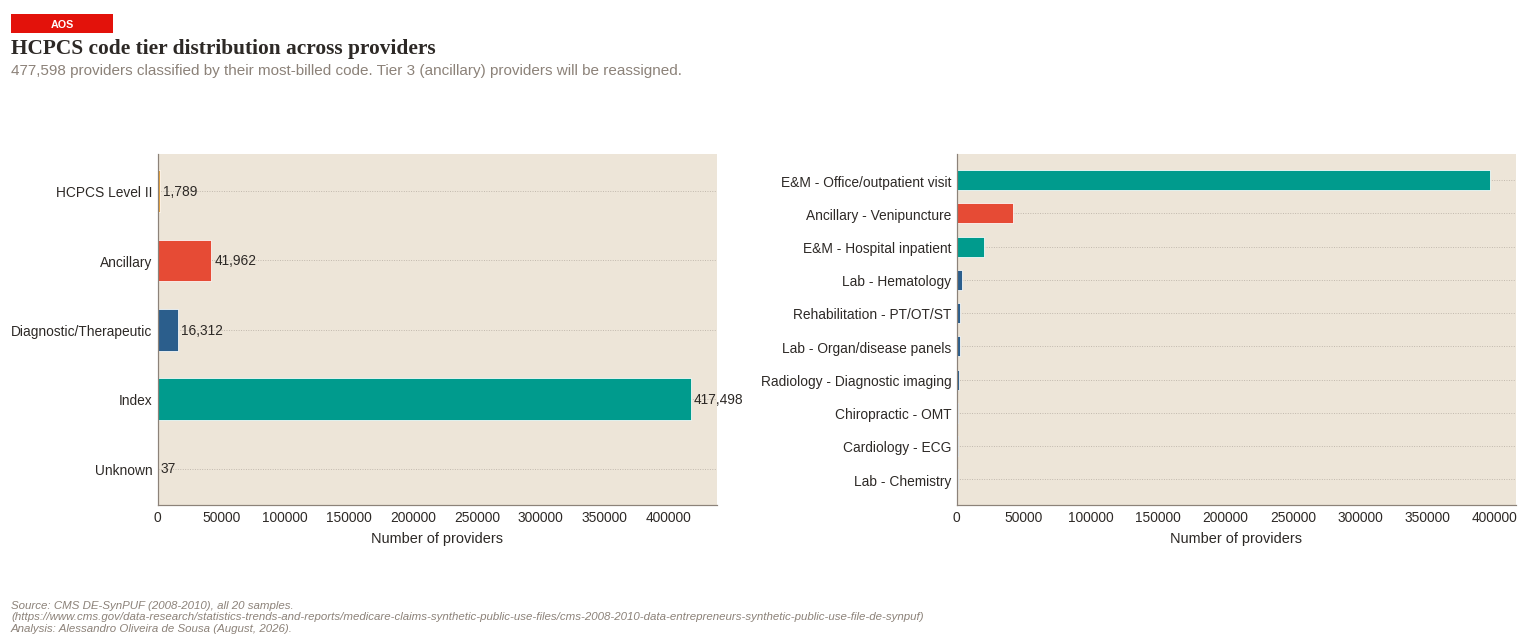

In [5]:
# =============================================================================
# Visual: HCPCS tier composition
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: tier distribution
tier_counts = df.groupby('top_code_tier').size().reset_index(name='count')
tier_counts['label'] = tier_counts['top_code_tier'].map(tier_names)
tier_colors = [WARM_GREY, NATURE_TEAL, DEEP_BLUE, NATURE_CORAL, AMBER]

ax = axes[0]
bars = ax.barh(tier_counts['label'], tier_counts['count'],
               color=[tier_colors[t] for t in tier_counts['top_code_tier']],
               edgecolor='white', linewidth=0.5, height=0.6)
for bar, val in zip(bars, tier_counts['count']):
    ax.text(bar.get_width() + len(df)*0.005, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, color=CHARCOAL)
adjust_axis(ax, xlabel='Number of providers')

# Right: top 10 categories
top10_cats = cat_summary.head(10)
ax = axes[1]
bars = ax.barh(range(len(top10_cats)), top10_cats['providers'],
               color=[tier_colors[int(t)] for t in top10_cats['top_code_tier']],
               edgecolor='white', linewidth=0.5, height=0.6)
ax.set_yticks(range(len(top10_cats)))
ax.set_yticklabels([truncar(c, 35) for c in top10_cats['top_code_category']], fontsize=8)
ax.invert_yaxis()
adjust_axis(ax, xlabel='Number of providers')

fig_title(fig,
          title='HCPCS code tier distribution across providers',
          subtitle=f'{len(df):,} providers classified by their most-billed code. '
                   f'Tier 3 (ancillary) providers will be reassigned.',
          top=0.82)
visual_identity(fig)
plt.savefig(FIGURES_DIR / 'hcpcs_tier_distribution.png')
plt.show()

## 3. Provider clinical identity

Providers whose top code is **Tier 3 (ancillary)** - like 36415 (venipuncture) - need to be reassigned to a more clinically meaningful peer group. Their top *index* code (Tier 1 or Tier 2) should determine their peer group.

Since the Snowflake export only has `top_hcpcs_code` (the single most-frequent code), we cannot compute the second-most-frequent code without re-scanning the carrier data. For Tier 3 providers, we fall back to the **broad specialty** derived from the overall HCPCS range.

In production with access to the full claim-line data, you would compute `top_index_code` as the most frequent Tier 1 or Tier 2 code per provider.

In [6]:
# =============================================================================
# Assign clinical identity: top index code (Tier 1/2), or fallback
# =============================================================================

# Providers with Tier 1 or 2 top codes → use that code directly
# Providers with Tier 3 (ancillary) → fall back to derived_specialty
# Providers with Tier 4 (Level II) → keep as-is (separate peer universe)

def assign_clinical_identity(row):
    if row['top_code_tier'] in (1, 2):
        return f"HCPCS_{row['top_hcpcs_code']}"
    elif row['top_code_tier'] == 3:
        return f"SPEC_{row['derived_specialty']}"  # Fallback
    elif row['top_code_tier'] == 4:
        return f"LVLII_{row['top_hcpcs_code']}"
    else:
        return f"SPEC_{row['derived_specialty']}"

df['clinical_identity'] = df.apply(assign_clinical_identity, axis=1)

# Count reassigned providers
n_tier3 = (df['top_code_tier'] == 3).sum()
n_reassigned = n_tier3  # All Tier 3 are reassigned

print(f"Clinical identity assignment:")
print("=" * 60)
print(f"  Direct (Tier 1/2 top code):     {(df['top_code_tier'].isin([1,2])).sum():>8,}")
print(f"  Reassigned (Tier 3 → specialty): {n_reassigned:>8,}")
print(f"  Level II (Tier 4):              {(df['top_code_tier'] == 4).sum():>8,}")
print(f"  Unknown (fallback):             {(df['top_code_tier'] == 0).sum():>8,}")

Clinical identity assignment:
  Direct (Tier 1/2 top code):      433,810
  Reassigned (Tier 3 → specialty):   41,962
  Level II (Tier 4):                 1,789
  Unknown (fallback):                   37


## 4. Peer group construction

### 4.1 Baseline: naive grouping (broad specialty × volume tier)

In [7]:
# =============================================================================
# Naive: broad specialty × volume tier
# =============================================================================

specialty_pcts = (df.groupby('derived_specialty')['total_lines']
                  .quantile([0.25, 0.75]).unstack()
                  .rename(columns={0.25: 'p25', 0.75: 'p75'}))
df = df.merge(specialty_pcts, on='derived_specialty')
df['volume_tier_naive'] = np.select(
    [df['total_lines'] < df['p25'], df['total_lines'] > df['p75']],
    ['Low', 'High'], default='Medium'
)
df = df.drop(columns=['p25', 'p75'])
df['peer_group_naive'] = df['derived_specialty'] + '_' + df['volume_tier_naive']

naive_group_count = df['peer_group_naive'].nunique()
print(f"Naive peer groups: {naive_group_count}")

Naive peer groups: 24


### 4.2 Improved: clinical-identity-level grouping

In [8]:
# =============================================================================
# Improved: clinical identity with min group size enforcement
# =============================================================================

identity_counts = df['clinical_identity'].value_counts()
viable_identities = identity_counts[identity_counts >= MIN_PEER_GROUP_SIZE].index

# Assign: viable identity → use it; otherwise → fall back to specialty
df['peer_group_improved'] = df.apply(
    lambda row: row['clinical_identity'] if row['clinical_identity'] in viable_identities
                else f"SPEC_{row['derived_specialty']}",
    axis=1
)

# Enforce MIN_PEER_GROUP_SIZE on final groups
group_sizes = df.groupby('peer_group_improved').size()
valid_groups = group_sizes[group_sizes >= MIN_PEER_GROUP_SIZE].index
df_valid = df[df['peer_group_improved'].isin(valid_groups)].copy()
df_valid['peer_group_size'] = df_valid.groupby('peer_group_improved')['provider_npi'].transform('count')

improved_group_count = df_valid['peer_group_improved'].nunique()
hcpcs_groups = df_valid['peer_group_improved'].str.startswith('HCPCS_').sum()
spec_groups = df_valid[df_valid['peer_group_improved'].str.startswith('SPEC_')]['peer_group_improved'].nunique()
lvlii_groups = df_valid[df_valid['peer_group_improved'].str.startswith('LVLII_')]['peer_group_improved'].nunique()

print(f"Improved peer groups: {improved_group_count}")
print(f"  HCPCS-level:        {improved_group_count - spec_groups - lvlii_groups} groups")
print(f"  Specialty fallback: {spec_groups} groups")
print(f"  Level II:           {lvlii_groups} groups")
print(f"  Providers retained: {len(df_valid):,}")

Improved peer groups: 120
  HCPCS-level:        100 groups
  Specialty fallback: 7 groups
  Level II:           13 groups
  Providers retained: 477,589


## 5. Statistical validation

### 5.1 Within-group homogeneity: per-code CoV comparison

We compare the Coefficient of Variation (CoV) of `avg_paid_per_line` for **the same set of providers** under naive vs improved grouping. If the HCPCS-level grouping is more homogeneous, the CoV should be lower for each code.

In [9]:
# =============================================================================
# Per-code CoV comparison: same providers, two groupings
# =============================================================================

# Select codes that are large enough for meaningful comparison
example_codes = (df_valid[df_valid['peer_group_improved'].str.startswith('HCPCS_')]
                 .groupby('top_hcpcs_code').size()
                 .nlargest(12).index.tolist())

comparison_rows = []
for hcpcs in example_codes:
    subset = df_valid[df_valid['top_hcpcs_code'] == hcpcs]
    if len(subset) < MIN_PEER_GROUP_SIZE:
        continue

    # CoV under naive: these providers are pooled into their broad specialty group
    naive_spec = subset['derived_specialty'].iloc[0]
    naive_pool = df[df['derived_specialty'] == naive_spec]
    naive_cov = naive_pool['avg_paid_per_line'].std() / naive_pool['avg_paid_per_line'].mean()

    # CoV under improved: only providers with this specific code
    improved_cov = subset['avg_paid_per_line'].std() / subset['avg_paid_per_line'].mean()

    comparison_rows.append({
        'HCPCS': hcpcs,
        'Specialty': naive_spec,
        'Naive pool': f"{len(naive_pool):,}",
        'HCPCS pool': f"{len(subset):,}",
        'CoV (naive)': round(naive_cov, 4),
        'CoV (improved)': round(improved_cov, 4),
        'Δ CoV (%)': round((improved_cov - naive_cov) / naive_cov * 100, 1),
        '_naive_cov': naive_cov,
        '_improved_cov': improved_cov,
    })

df_cov = pd.DataFrame(comparison_rows)

render_table(
    df_cov.drop(columns=['_naive_cov', '_improved_cov']),
    title='Within-group CoV: naive vs HCPCS-level grouping (same providers)',
    fmt={'CoV (naive)': '{:.4f}', 'CoV (improved)': '{:.4f}', 'Δ CoV (%)': '{:+.1f}%'}
)

n_improved = (df_cov['_improved_cov'] < df_cov['_naive_cov']).sum()
print(f"\n{n_improved}/{len(df_cov)} codes show lower CoV under HCPCS grouping.")

HCPCS,Specialty,Naive pool,HCPCS pool,CoV (naive),CoV (improved),Δ CoV (%)
99213,Evaluation & Management,"417,253","322,320",0.1581,0.1506,-4.7%
99214,Evaluation & Management,"417,253","73,482",0.1581,0.1769,+11.9%
99232,Evaluation & Management,"417,253","18,360",0.1581,0.1825,+15.4%
85025,Pathology & Lab,"7,868","2,614",0.2251,0.2191,-2.7%
97110,Medicine,"7,025","2,098",0.2209,0.2085,-5.6%
80053,Pathology & Lab,"7,868","1,599",0.2251,0.2136,-5.1%
99233,Evaluation & Management,"417,253","1,442",0.1581,0.1914,+21.1%
98941,Medicine,"7,025","1,073",0.2209,0.2236,+1.2%
85610,Pathology & Lab,"7,868","1,039",0.2251,0.2185,-3.0%
93010,Medicine,"7,025",930,0.2209,0.2231,+1.0%



7/12 codes show lower CoV under HCPCS grouping.


**Note on E&M codes with higher CoV (99214, 99232, 99233):** Three E&M codes show *increased* CoV under HCPCS-level grouping. This is expected and not a defect. The broad "Evaluation & Management" group is 69% code 99213 (routine office visit, tight payment distribution), which dominates the group mean and suppresses overall CoV. When higher-complexity codes like 99232 (subsequent hospital care) and 99233 (high-complexity hospital care) are isolated, their inherent billing variance is wider because legitimate clinical variation is greater - a hospitalist managing a post-surgical ICU patient has a fundamentally different cost profile than one managing a stable observation patient, even though both bill 99233. Comparing within these codes is still more meaningful than comparing them against 99213 office visits, even if the within-group CoV is numerically higher.

### 5.2 Kolmogorov-Smirnov test: distribution tightness

For each example code, we test whether the within-group payment distribution under improved grouping is significantly *tighter* (lower variance) than under naive grouping. A significant K-S test result confirms the distributions are different.

In [10]:
# =============================================================================
# K-S test: naive vs improved within-group distributions
# =============================================================================

ks_results = []
for hcpcs in example_codes:
    subset = df_valid[df_valid['top_hcpcs_code'] == hcpcs]
    naive_spec = subset['derived_specialty'].iloc[0]
    naive_pool = df[df['derived_specialty'] == naive_spec]

    if len(subset) < 20 or len(naive_pool) < 20:
        continue

    stat, pvalue = stats.ks_2samp(
        subset['avg_paid_per_line'].dropna(),
        naive_pool['avg_paid_per_line'].dropna()
    )

    ks_results.append({
        'HCPCS': hcpcs,
        'K-S statistic': round(stat, 4),
        'p-value': f"{pvalue:.2e}" if pvalue < 0.001 else f"{pvalue:.4f}",
        'Significant': '✓ Yes (p<0.001)' if pvalue < 0.001 else 'No',
    })

df_ks = pd.DataFrame(ks_results)
render_table(df_ks, title='Kolmogorov-Smirnov test: naive pool vs HCPCS-level pool')

n_sig = sum(1 for r in ks_results if 'Yes' in r['Significant'])
print(f"\n{n_sig}/{len(ks_results)} codes show significantly different distributions (p<0.001).")
print("This confirms that pooling diverse codes into a single specialty group")
print("distorts the reference distribution for peer comparison.")

HCPCS,K-S statistic,p-value,Significant
99213,0.015300,1.76e-37,✓ Yes (p<0.001)
99214,0.044300,6.12e-107,✓ Yes (p<0.001)
99232,0.126400,1.80e-245,✓ Yes (p<0.001)
85025,0.015100,0.7583,No
97110,0.051700,3.37e-04,✓ Yes (p<0.001)
80053,0.046700,0.0059,No
99233,0.190400,4.31e-46,✓ Yes (p<0.001)
98941,0.046200,0.0363,No
85610,0.043400,0.0609,No
93010,0.108900,6.06e-09,✓ Yes (p<0.001)



7/12 codes show significantly different distributions (p<0.001).
This confirms that pooling diverse codes into a single specialty group
distorts the reference distribution for peer comparison.


### 5.3 Levene's test: equality of variances across peer groups

If variances differ significantly across peer groups, a z-score of 2.0 means something different in each group. Levene's test (Brown-Forsythe variant, robust to non-normality) tests this.

In [11]:
# =============================================================================
# Levene's test across improved peer groups
# =============================================================================

# Select top 20 peer groups by size for the test
top_groups = (df_valid.groupby('peer_group_improved').size()
              .nlargest(20).index.tolist())

groups_data = [df_valid.loc[df_valid['peer_group_improved'] == g, 'avg_paid_per_line'].dropna().values
               for g in top_groups]

# Brown-Forsythe (center='median') - robust to non-normality
levene_stat, levene_p = stats.levene(*groups_data, center='median')

print(f"Levene's test (Brown-Forsythe) for equality of variances:")
print(f"  Groups tested: {len(top_groups)} (top peer groups by size)")
print(f"  Statistic:     {levene_stat:.4f}")
print(f"  p-value:       {levene_p:.2e}")
print(f"  Result:        {'Variances differ significantly (p<0.001)' if levene_p < 0.001 else 'Variances are homogeneous'}")
print(f"\nImplication: {'Z-score thresholds should be interpreted with caution across groups.' if levene_p < 0.001 else 'Z-scores are comparable across groups.'}")
print(f"The composite risk score in NB05 accounts for this by including a")
print(f"peer_group_size_penalty that down-weights scores from less reliable groups.")

Levene's test (Brown-Forsythe) for equality of variances:
  Groups tested: 20 (top peer groups by size)
  Statistic:     428.8047
  p-value:       0.00e+00
  Result:        Variances differ significantly (p<0.001)

Implication: Z-score thresholds should be interpreted with caution across groups.
The composite risk score in NB05 accounts for this by including a
peer_group_size_penalty that down-weights scores from less reliable groups.


### 5.4 Visual comparison

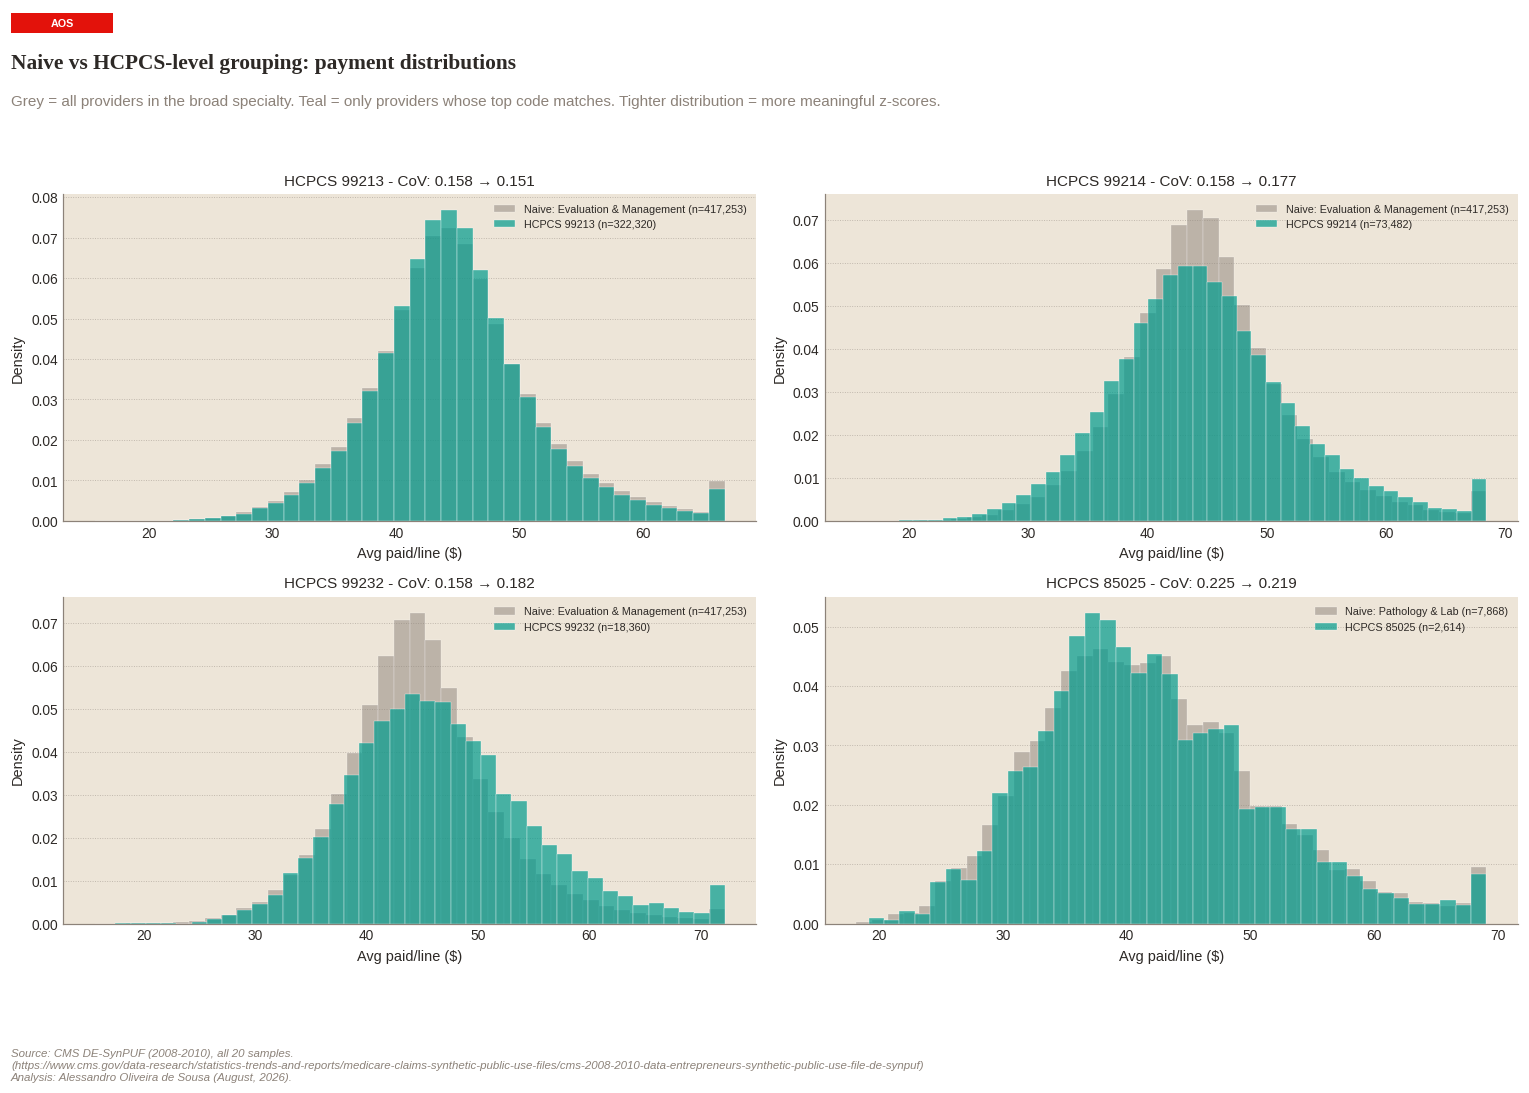

In [12]:
# =============================================================================
# Visual: payment distributions for 4 example codes - naive pool vs HCPCS pool
# =============================================================================

plot_codes = example_codes[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, hcpcs in zip(axes.flatten(), plot_codes):
    subset = df_valid[df_valid['top_hcpcs_code'] == hcpcs]
    naive_spec = subset['derived_specialty'].iloc[0]
    naive_pool = df[df['derived_specialty'] == naive_spec]

    # Truncate at P99 for readability
    upper = max(naive_pool['avg_paid_per_line'].quantile(0.99),
                subset['avg_paid_per_line'].quantile(0.99))

    ax.hist(naive_pool['avg_paid_per_line'].clip(upper=upper), bins=40,
            alpha=0.5, color=WARM_GREY, edgecolor='white', linewidth=0.3,
            label=f'Naive: {naive_spec} (n={len(naive_pool):,})', density=True)
    ax.hist(subset['avg_paid_per_line'].clip(upper=upper), bins=40,
            alpha=0.7, color=NATURE_TEAL, edgecolor='white', linewidth=0.3,
            label=f'HCPCS {hcpcs} (n={len(subset):,})', density=True)

    naive_cov = naive_pool['avg_paid_per_line'].std() / naive_pool['avg_paid_per_line'].mean()
    improved_cov = subset['avg_paid_per_line'].std() / subset['avg_paid_per_line'].mean()

    ax.set_title(f'HCPCS {hcpcs} - CoV: {naive_cov:.3f} → {improved_cov:.3f}', fontsize=10)
    adjust_axis(ax, xlabel='Avg paid/line ($)', ylabel='Density')
    ax.legend(fontsize=7, loc='upper right')

fig_title(fig,
          title='Naive vs HCPCS-level grouping: payment distributions',
          subtitle='Grey = all providers in the broad specialty. Teal = only providers whose top code matches. '
                   'Tighter distribution = more meaningful z-scores.',
          top=0.88)
visual_identity(fig)
plt.savefig(FIGURES_DIR / 'naive_vs_improved_distributions.png')
plt.show()

## 6. Export

Two outputs for Notebook 02b:
1. The full provider dataset with peer group assignments and code classification
2. The code classification table (for reference and documentation)

In [13]:
# =============================================================================
# Export
# =============================================================================

# 1. Provider dataset with peer groups
export_path_providers = OUTPUT_DIR / 'nb02a_providers_with_peer_groups.csv'
df_valid.to_csv(export_path_providers, index=False)
print(f"Exported providers: {len(df_valid):,} rows × {len(df_valid.columns)} cols")
print(f"  File: {export_path_providers}")

# 2. Code classification table
export_path_codes = OUTPUT_DIR / 'nb02a_hcpcs_classification.csv'
code_classification.to_csv(export_path_codes, index=False)
print(f"\nExported code classification: {len(code_classification):,} codes")
print(f"  File: {export_path_codes}")

print(f"\nProceed to: Notebook 02b (provider profiling & clustering)")

Exported providers: 477,589 rows × 28 cols
  File: /home/aosousa/Documents/PORTFOLIO/Fraud-Waste-Abuse-FWA/CMS DE-SynPUF MEDICARE/provider-aberrant-billing-detection/outputs/nb02a_providers_with_peer_groups.csv

Exported code classification: 504 codes
  File: /home/aosousa/Documents/PORTFOLIO/Fraud-Waste-Abuse-FWA/CMS DE-SynPUF MEDICARE/provider-aberrant-billing-detection/outputs/nb02a_hcpcs_classification.csv

Proceed to: Notebook 02b (provider profiling & clustering)


In [15]:
print("=" * 70)
print("Notebook 02a - Procedure Profiling & Peer Grouping - Summary")
print("=" * 70)
print(f"  Providers loaded:              {before:,}")
print(f"  After MIN_CLAIMS filter:       {len(df):,}")
print(f"  HCPCS codes classified:        {len(code_classification):,}")
print(f"  Tier 3 (ancillary) reassigned: {n_reassigned:,}")
print(f"  Naive peer groups:             {naive_group_count}")
print(f"  Improved peer groups:          {improved_group_count}")
print(f"  Providers in valid groups:     {len(df_valid):,}")
n_ks = sum(1 for r in ks_results if 'Yes' in r['Significant'])
print(f"  K-S tests significant:         {n_ks}/{len(ks_results)} codes")
print(f"  Levene's test p-value:         {levene_p:.2e}")
print("=" * 70)

Notebook 02a - Procedure Profiling & Peer Grouping - Summary
  Providers loaded:              893,020
  After MIN_CLAIMS filter:       477,598
  HCPCS codes classified:        504
  Tier 3 (ancillary) reassigned: 41,962
  Naive peer groups:             24
  Improved peer groups:          120
  Providers in valid groups:     477,589
  K-S tests significant:         7/12 codes
  Levene's test p-value:         0.00e+00
